### Load Dependencies

In [1]:
import torch
import torch.optim as optim
import torch.distributed as dist
from torch.utils.data import DataLoader
import numpy as np
import src.loss_functions as loss_functions
from torch.utils.data import SubsetRandomSampler

from src.dataset import DSMShadeDataset
from src.model import ShadyModel

### Define Parameters

In [2]:
# Directory containing training data
TEST_TILE_PATH = "/Users/luc/Geomatics/Thesis/Data/input/271110_Ams/test_tiles/dsms/combined/"
TEST_SHADE_PATH = "/Users/luc/Geomatics/Thesis/Data/output/tree_shade/"
CSV_PATH = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/resources/dataset.csv"
STATE_DICT_DIR = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/resources/"

# Set Acceleration Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)
# Hyperparameters
tile_size = 512
epochs = 10
LAMBDA = 100
optimizer_learning_rate = 0.0002
# Todo experiment with not messing with this value? (defined in DCGAN paper apparently)
optimizer_momentum = 0.5
# # Todo, how to find how many GPUS are available?
ngpu = 1
if device == torch.device("cpu"):
    ngpu = 0

mps


In [3]:
# Instantiate the custom dataset
dataset = DSMShadeDataset(CSV_PATH, TEST_TILE_PATH, TEST_SHADE_PATH, tile_size=tile_size, max_cache=150)

# Define train and test dataloaders
batch_size = 24
validation_split = .2
shuffle_dataset = True
random_seed = 42

# Creating data indices for training and validation splits:
dataset_size = len(dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
if shuffle_dataset:
    np.random.seed(random_seed)
    np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

# Create data samplers and loaders:
train_sampler = SubsetRandomSampler(train_indices)
valid_sampler = SubsetRandomSampler(val_indices)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
validation_loader = DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler)

print(len(train_loader), len(validation_loader))

824 206


In [4]:
model = ShadyModel(ngpu, device)
model.setup_models(state_dict_dir=STATE_DICT_DIR)
disc_optimizer = optim.Adam(params=model.discriminator.parameters(), lr=optimizer_learning_rate,
                            betas=(optimizer_momentum, 0.999))
gen_optimizer = optim.Adam(params=model.generator.parameters(), lr=optimizer_learning_rate,
                           betas=(optimizer_momentum, 0.999))

### Training Loop

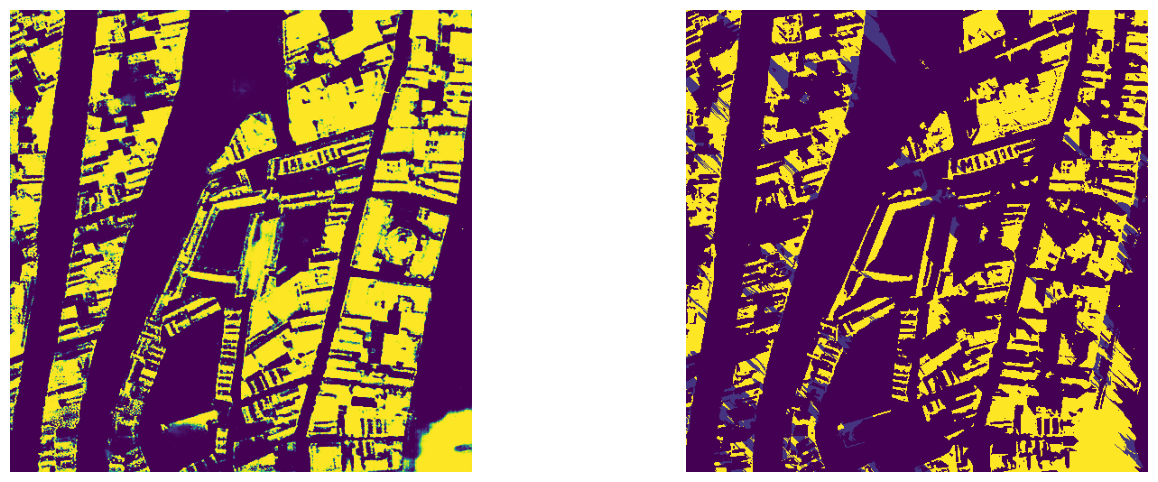

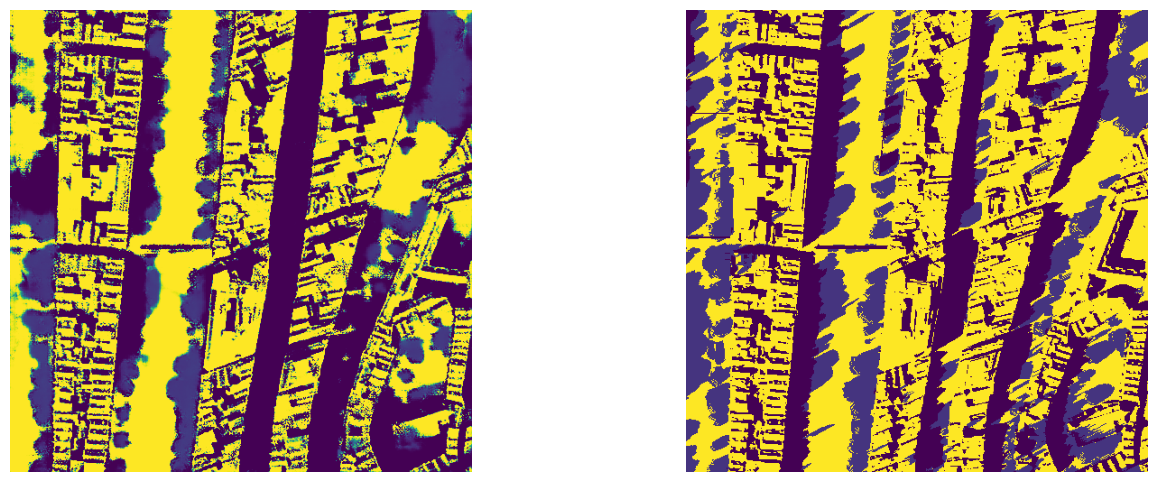

Epoch 2 stop


In [5]:
from src.utils import Sobel
from matplotlib import pyplot as plt


def display_res(result, target):
    result_cpu = result.cpu().detach()
    target_cpu = target.cpu().detach()

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    result = result_cpu[0]
    plt.imshow(result.squeeze().numpy())
    plt.axis('off')

    plt.subplot(1, 2, 2)
    result = target_cpu[0]
    plt.imshow(result.squeeze().numpy())
    plt.axis('off')

    plt.set_cmap("viridis")
    plt.show()


sobel = Sobel(device)
y_hat = None
target = None
# Todo include epochs
for epoch in range(epochs):
    if y_hat is not None and target is not None:
        display_res(y_hat, target)

    if epoch == 2:
        print("Epoch 2 stop")
        break
    for i, data in enumerate(train_loader, 0):
        source = data["source"]
        target = data["target"]
        source, target = source.to(device), target.to(device)

        ### DISCRIMINATOR TRAINING LOOP ###
        disc_optimizer.zero_grad()
        y_hat = model.generator(source)
        discriminator_real = model.discriminator(source, target)
        discriminator_generated = model.discriminator(source, y_hat)
        disc_loss = loss_functions.discriminator_loss(discriminator_real, discriminator_generated)
        disc_loss.backward(retain_graph=True)
        disc_optimizer.step()

        ### GENERATOR TRAINING LOOP ###
        gen_optimizer.zero_grad()
        discriminator_output = model.discriminator(source, y_hat)
        gen_loss = loss_functions.generator_loss(discriminator_output, y_hat, target, LAMBDA, sobel)
        gen_loss.backward()
        gen_optimizer.step()

In [6]:
model.save(STATE_DICT_DIR, generator_only=False)